# Imports

In [1]:
# Linear algebra
import numpy as np

# Dataframes
import pandas as pd

# Path
import os
data_path = os.path.join('..', 'data', 'human_viruses')

# Plotting
import seaborn as sns
import matplotlib.pyplot as plt

# Translate codons to amino acids
from Bio.Seq import Seq

# Load Data

In [2]:
human_viruses = pd.read_pickle(os.path.join(data_path, 'human_viruses.pkl'))
train_df = human_viruses
test_df = human_viruses

# Frequency Based Models

## Harmonizer

### Utils

In [29]:
def get_dna_codons():
  nt_bases = ['A', 'C', 'G', 'T']
  codons = [c1 + c2 + c3 for c1 in nt_bases for c2 in nt_bases for c3 in nt_bases]
  return codons

# Create a dictionary mapping amino acids to all possible codons
def get_amino_acid_codon_dict():
  codons = get_dna_codons()
  
  amino_acid_codon_dict = {}
  for codon in codons:
    aa = str(Seq(codon).translate())
    if aa not in amino_acid_codon_dict:
      amino_acid_codon_dict[aa] = []
    amino_acid_codon_dict[aa].append(codon)
  return amino_acid_codon_dict



### Harmonizer Class

In [30]:
class Harmonizer:

    def __init__(self, train_X, train_Y, verbose=False):
        """Get aa sequences X and codon sequences Y pandas columns.

        Create Frequency Based Model."""
        self.train_X = train_X
        self.train_Y = train_Y

        if verbose:
            print("--- Training Frequency Model ---")

        # Create a DataFrame from the nucleotide and amino acid sequences
        self.train_df = pd.DataFrame({'amino_acids': train_X, 'nucleotides': train_Y})
        
        if verbose:
            print("    * Calculating Codon Fractions...")
        
        self._amino_acid_codon_dict, \
        self._amino_acid_codon_frac_dict = self.calculate_amino_acid_codon_frac_dict()

        if verbose:
            print("    * Finding Most Frequent Codon for each Amino Acid...")
        
        self._amino_acid_most_freq_codon_dict = self.calculate_amino_acid_most_freq_codon_dict()

        if verbose:
            print("--- Training Finished! ---")

    # Create a dictionary mapping amino acids to list of codon frequencies
    def calculate_amino_acid_codon_frac_dict(self):
        amino_acid_codon_dict = get_amino_acid_codon_dict()

        amino_acid_codon_frac_dict = {aa: [0 for _ in amino_acid_codon_dict[aa]] for aa in amino_acid_codon_dict.keys()}

        total_counts = {aa: 0 for aa in amino_acid_codon_dict.keys()}

        for seq, aa_seq in zip(self.train_Y, self.train_X):
            codon_list = [seq[i:i+3] for i in range(0, len(seq), 3)]
            aa_seq = str(Seq(seq).translate())

            for aa, codon in zip(aa_seq, codon_list):
                if codon in amino_acid_codon_dict[aa]:
                    codon_index = amino_acid_codon_dict[aa].index(codon)
                    amino_acid_codon_frac_dict[aa][codon_index] += 1
                    total_counts[aa] += 1

        for aa, codons in amino_acid_codon_frac_dict.items():
            for i in range(len(codons)):
                if total_counts[aa] > 0:
                    amino_acid_codon_frac_dict[aa][i] /= total_counts[aa]

        return amino_acid_codon_dict, amino_acid_codon_frac_dict

    # Create a dictionary mapping amino acids to most frequent codon
    def calculate_amino_acid_most_freq_codon_dict(self):
        amino_acid_most_freq_codon_dict = {}
        for aa, codons in self._amino_acid_codon_frac_dict.items():
            most_freq_index = np.argmax(codons)
            amino_acid_most_freq_codon_dict[aa] = self._amino_acid_codon_dict[aa][most_freq_index]
        return amino_acid_most_freq_codon_dict

    def predict_codons(self, amino_acid_sequences, verbose=False):
        """Predict the codon sequences for a pandas column of amino acid sequences."""
        
        if verbose:
            print("Predicting codons for amino acid sequences...")
            # Vectorized prediction
        def predict_sequence(aa_seq):
            return ''.join(self._amino_acid_most_freq_codon_dict[aa] for aa in aa_seq)

        predicted_codons = amino_acid_sequences.apply(predict_sequence)
        return predicted_codons.tolist()
    
    def calculate_accuracies(self, predictions, ground_truth, verbose=False):
        accuracies = []
        for pred, gt in zip(predictions, ground_truth):
            correct = sum([1 for p, g in zip([pred[i:i+3] for i in range(0, len(pred), 3)], [gt[i:i+3] for i in range(0, len(gt), 3)]) if p == g])
            assert len(gt) % 3 == 0
            total = len(gt) // 3
            accuracies.append(correct / total)
        return accuracies

       

### Train and Test Harmoizer

In [31]:
train_df['amino_acid_seq'] = train_df['codon_seq'].apply(lambda x: str(Seq(x).translate()))

In [32]:
# Example inputs for training
nt_sequences = train_df['codon_seq']
aa_sequences = train_df['amino_acid_seq']

# Create an instance of Frequency_Model
harmonizer_model = Harmonizer(aa_sequences, nt_sequences, verbose=True)


--- Training Frequency Model ---
    * Calculating Codon Fractions...
    * Finding Most Frequent Codon for each Amino Acid...
--- Training Finished! ---


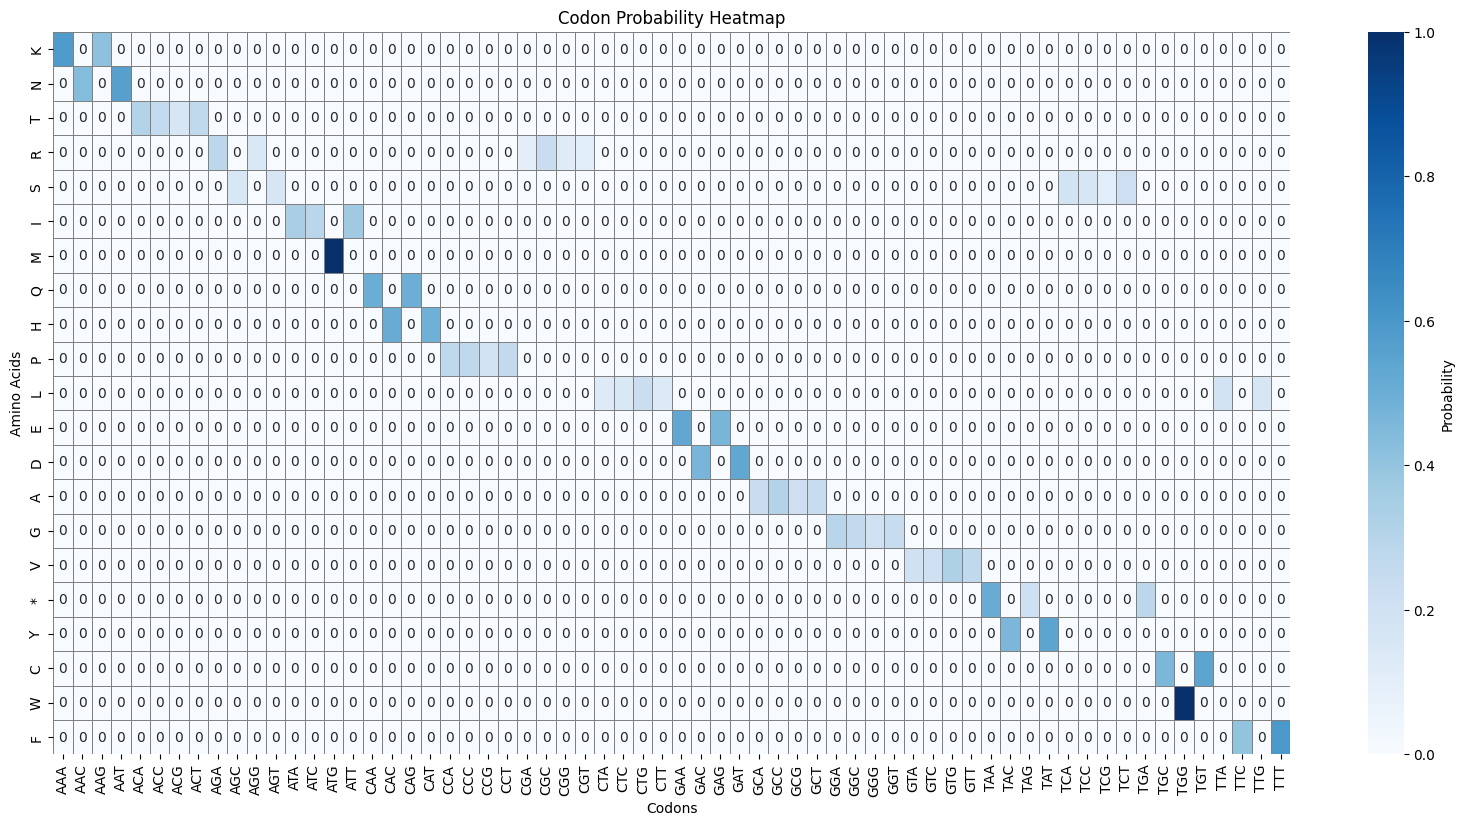

In [33]:
# harmonizer_model._amino_acid_codon_frac_dict

# For each amino acid, list of all possible codons and their relevant fractions (0 if not present)
all_codons = get_dna_codons()

# Initialize a dictionary with all possible codons for each amino acid
amino_acid_codon_frac_dict_full = {aa: [0] * len(all_codons) for aa in harmonizer_model._amino_acid_codon_frac_dict.keys()}

# Fill in the fractions for the codons that are present
for aa, codons in harmonizer_model._amino_acid_codon_frac_dict.items():
    for codon, frac in zip(harmonizer_model._amino_acid_codon_dict[aa], codons):
        index = all_codons.index(codon)
        amino_acid_codon_frac_dict_full[aa][index] = frac

amino_acid_codon_frac_dict_full

plt.figure(figsize=(16, 8))

# Custom annotation function to label only tiles with exactly 0 value
def annot_func(data):
    return data.map(lambda v: '0' if v == 0 else '')

htmap = sns.heatmap(pd.DataFrame(amino_acid_codon_frac_dict_full).T, cmap='Blues', linewidths=0.5, linecolor='grey', annot=annot_func(pd.DataFrame(amino_acid_codon_frac_dict_full).T), fmt='', cbar_kws={'label': 'Probability'}, cbar=True, xticklabels=all_codons)
htmap.figure.tight_layout()
plt.title("Codon Probability Heatmap")
plt.xlabel("Codons")
plt.ylabel("Amino Acids")

plt.savefig('codon_probability_heatmap.svg', format='svg', bbox_inches='tight')

plt.show()

In [34]:
test_nt_seq = test_df['codon_seq']
test_aa_seq = test_df['amino_acid_seq']

pred = harmonizer_model.predict_codons(test_aa_seq, verbose=True)
mfc_accuracies = harmonizer_model.calculate_accuracies(pred, test_nt_seq, verbose=True)
np.mean(mfc_accuracies)

Predicting codons for amino acid sequences...


np.float64(0.41394221815310644)

In [35]:
# save test_df predictions and accuracies columns as pickle
print("Saving predictions and accuracies...")
pd.DataFrame({'mfc_prediction':pred, 
              'mfc_accuracy':mfc_accuracies}).to_pickle(os.path.join(data_path, "test_mfc.pkl"))

Saving predictions and accuracies...


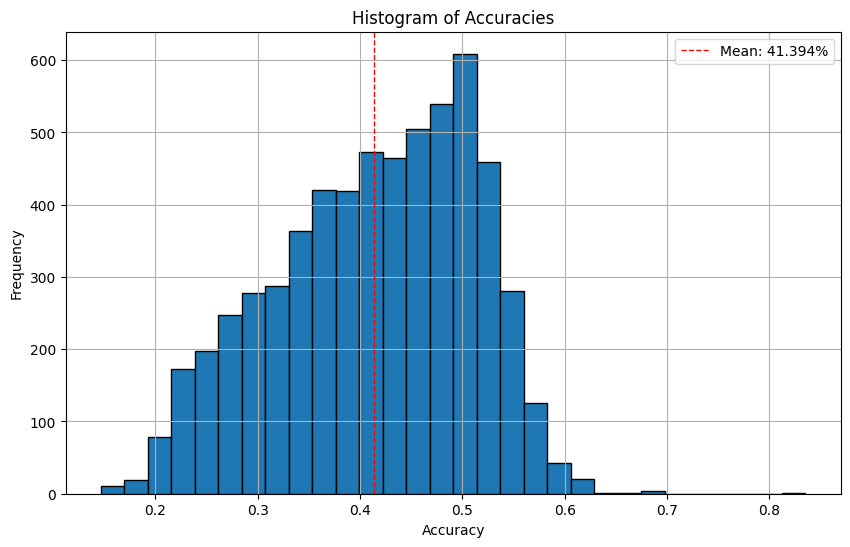

In [36]:
mean_accuracy = np.mean(mfc_accuracies)

plt.figure(figsize=(10, 6))
plt.hist(mfc_accuracies, bins=30, edgecolor='black')
plt.axvline(mean_accuracy, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {mean_accuracy * 100:.3f}%')

plt.title('Histogram of Accuracies')
plt.xlabel('Accuracy')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)

plt.savefig('mfc_accuracy_histogram.svg', format='svg', bbox_inches='tight')

plt.show()

## Random Synonymous Codon

### Random Harmonizer Class

In [37]:
class RandomHarmonizer:

    def __init__(self, verbose=False):
        self.verbose = verbose
        self.aa_to_codons = get_amino_acid_codon_dict()

    def predict_codons(self, amino_acid_sequences, verbose=False):
        """Predict the codon sequences for a pandas column of amino acid sequences."""
        
        if verbose:
            print("Predicting codons for amino acid sequences...")
        
        # Vectorized prediction using pandas apply with a lambda function
        predicted_codons = amino_acid_sequences.apply(
            lambda aa_seq: ''.join(np.random.choice(self.aa_to_codons[aa]) for aa in aa_seq)
        )
        return predicted_codons.tolist()
    
    def calculate_accuracies(self, predictions, ground_truth, verbose=False):
        """Calculate accuracies for predictions against ground truth."""
        
        if verbose:
            print("Calculating accuracies...")
        
        # Vectorized calculation of accuracies
        def calculate_accuracy(pred, gt):
            codons_pred = [pred[i:i+3] for i in range(0, len(pred), 3)]
            codons_gt = [gt[i:i+3] for i in range(0, len(gt), 3)]
            correct = sum(p == g for p, g in zip(codons_pred, codons_gt))
            return correct / len(codons_gt)
        
        accuracies = [calculate_accuracy(pred, gt) for pred, gt in zip(predictions, ground_truth)]
        return accuracies


### Test Random Harmoizer

In [38]:
test_df['amino_acid_seq'] = test_df['codon_seq'].apply(lambda x: str(Seq(x).translate()))

# Create an instance of Frequency_Model
random_harmonizer_model = RandomHarmonizer(verbose=True)

test_nt_seq = test_df['codon_seq']
test_aa_seq = test_df['amino_acid_seq']

pred = random_harmonizer_model.predict_codons(test_aa_seq, verbose=True)
rsc_accuracies = random_harmonizer_model.calculate_accuracies(pred, test_nt_seq, verbose=True)
np.mean(rsc_accuracies)

Predicting codons for amino acid sequences...
Calculating accuracies...


np.float64(0.3561041164504143)

In [39]:
# save test_df Random Synonymous Codon (RSC) predictions and accuracies columns as pickle
print("Saving predictions and accuracies...")
pd.DataFrame({'rsc_prediction':pred, 
              'rsc_accuracy':rsc_accuracies}).to_pickle(os.path.join(data_path, "test_rsc.pkl"))

Saving predictions and accuracies...


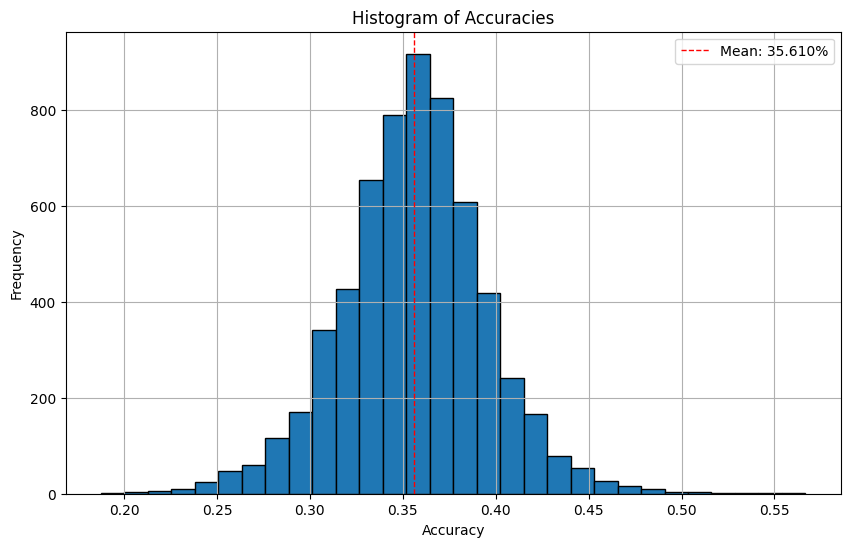

In [40]:
rsc_accuracies = pd.read_pickle(os.path.join(data_path, "test_rsc.pkl"))['rsc_accuracy']
mean_accuracy = np.mean(rsc_accuracies)

plt.figure(figsize=(10, 6))
plt.hist(rsc_accuracies, bins=30, edgecolor='black')
plt.axvline(mean_accuracy, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {mean_accuracy * 100:.3f}%')

plt.title('Histogram of Accuracies')
plt.xlabel('Accuracy')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)

plt.show()

## Bi-codon Harmonizer

### Bi-Codon Harmonizer Class

In [16]:
class BiCodonHarmonizer:

    def __init__(self, train_X, train_Y, verbose=False):
        """Get aa sequences X and codon sequences Y pandas columns.

        Create Frequency Based Model for bi-codons."""
        self.train_X = train_X
        self.train_Y = train_Y

        if verbose:
            print("--- Training Bi-Codon Frequency Model ---")

        # Create a DataFrame from the nucleotide and amino acid sequences
        self.train_df = pd.DataFrame({'amino_acids': train_X, 'nucleotides': train_Y})
        
        if verbose:
            print("    * Extracting codons...")

        # Extract codons and corresponding amino acids
        self.train_df['codons'] = self.train_df['nucleotides'].str.extractall(r'(.{3})').groupby(level=0).agg(list)
        self.train_df['amino_acids'] = self.train_df['amino_acids'].apply(list)

        if verbose:
            print("    * Creating bi-codon pairs...")

        # Create bi-codon pairs
        self.train_df['bi_codons'] = self.train_df['codons'].apply(lambda x: [x[i] + " " + x[i+1] for i in range(len(x)-1)])
        self.train_df['bi_amino_acids'] = self.train_df['amino_acids'].apply(lambda x: [x[i] + " " + x[i+1] for i in range(len(x)-1)])

        if verbose:
            print("    * Calculating Frequencies...")

        # Initialize dictionaries for bi-codon frequencies and probabilities
        self.bi_codon_freq = {}
        self.bi_codon_prob = {}

        # Count the frequency of each bi-codon for each bi-amino acid
        for bi_aa, bi_codon in zip(self.train_df['bi_amino_acids'].explode(), self.train_df['bi_codons'].explode()):
            if bi_aa not in self.bi_codon_freq:
                self.bi_codon_freq[bi_aa] = {}
            if bi_codon not in self.bi_codon_freq[bi_aa]:
                self.bi_codon_freq[bi_aa][bi_codon] = 0
            self.bi_codon_freq[bi_aa][bi_codon] += 1

        # Normalize the frequencies to get probabilities
        for bi_aa, codon_dict in self.bi_codon_freq.items():
            total_count = sum(codon_dict.values())
            self.bi_codon_prob[bi_aa] = {codon: count / total_count for codon, count in codon_dict.items()}

        if verbose:
            print("--- Training Finished! ---")

    def predict_codons(self, amino_acid_sequences, verbose=False):
        """Predict the codon sequences for a pandas column of amino acid sequences."""
        
        if verbose:
            print("Predicting codons for amino acid sequences...")

        def predict_sequence(seq):
            predicted_codons = ['ATG']  # Start codon
            bi_aa_pairs = [seq[i-1] + " " + seq[i] for i in range(1, len(seq))]
            
            for bi_aa in bi_aa_pairs:
                prev_codon = predicted_codons[-1]
                bi_codon_candidates = {k: v for k, v in self.bi_codon_prob.get(bi_aa, {}).items() if k.startswith(prev_codon)}
                if bi_codon_candidates:
                    bi_codon = max(bi_codon_candidates, key=bi_codon_candidates.get)
                    predicted_codons.append(bi_codon.split(" ")[1])
                else:
                    predicted_codons.append('NNN')  # Default to 'NNN' if no suitable bi-codon is found
            
            return ''.join(predicted_codons)
        
        predicted_codons = amino_acid_sequences.apply(predict_sequence)
        return predicted_codons.tolist()

    def calculate_accuracies(self, predictions, ground_truth, verbose=False):
        """Get model list of predictions and ground truth and return average accuracy"""

        if verbose:
            print("Calculating accuracy...")

        accuracies = []
        for pred, gt in zip(predictions, ground_truth):
            correct = sum([1 for p, g in zip([pred[i:i+3] for i in range(0, len(pred), 3)], [gt[i:i+3] for i in range(0, len(gt), 3)]) if p == g])
            assert len(gt) % 3 == 0
            total = len(gt) // 3
            accuracies.append(correct / total)
        return accuracies

### Train and Test Bi-Codon Harmonizer

In [17]:
# training inputs
nt_sequences = train_df['codon_seq']
aa_sequences = train_df['amino_acid_seq']

# train bi-codon model
bi_codon_harmonizer_model = BiCodonHarmonizer(aa_sequences, nt_sequences, verbose=True)

--- Training Bi-Codon Frequency Model ---
    * Extracting codons...
    * Creating bi-codon pairs...
    * Calculating Frequencies...
--- Training Finished! ---


In [18]:
# Test bi-codon model
test_nt_seq = human_viruses['codon_seq']
test_aa_seq = human_viruses['amino_acid_seq']

bi_codon_pred = bi_codon_harmonizer_model.predict_codons(test_aa_seq, verbose=True)
bi_codon_accuracy = bi_codon_harmonizer_model.calculate_accuracies(bi_codon_pred, test_nt_seq, verbose=True)

print(f"Bi-Codon Harmonizer Accuracy: {np.mean(bi_codon_accuracy)}")

Predicting codons for amino acid sequences...
Calculating accuracy...
Bi-Codon Harmonizer Accuracy: 0.40541922278002973


In [19]:
# save test_df predictions and accuracies columns as pickle
print("Saving predictions and accuracies...")
pd.DataFrame({'mfb_prediction':bi_codon_pred, 
              'mfb_accuracy':bi_codon_accuracy}).to_pickle(os.path.join(data_path, "2_50_mfb.pkl"))

Saving predictions and accuracies...


In [20]:
mean_accuracy

np.float64(0.35687810504868633)

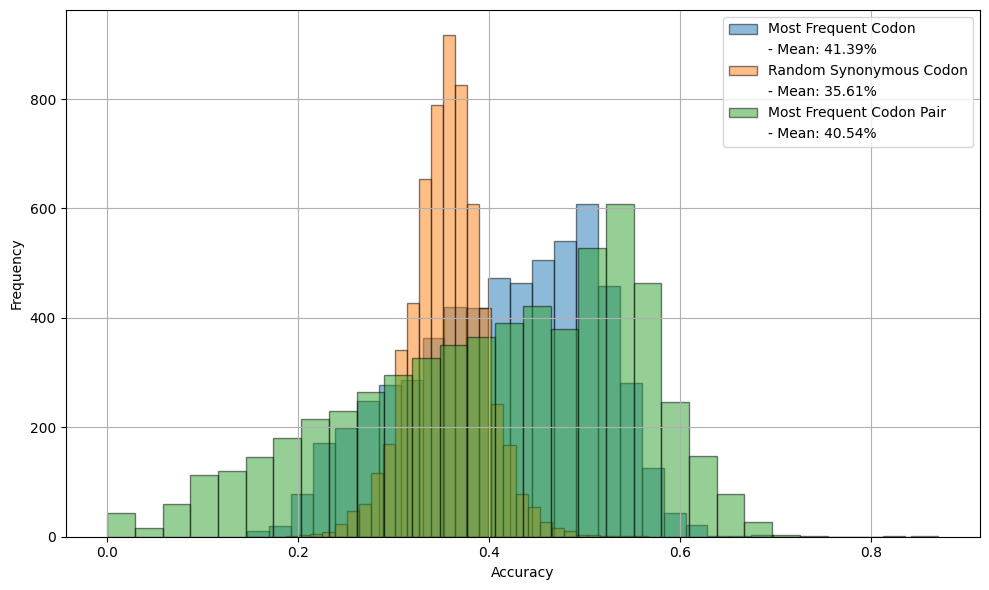

In [49]:
mfc_mean_accuracy = np.mean(mfc_accuracies)
rsc_mean_accuracy = np.mean(rsc_accuracies)
mean_bi_codon_accuracy = np.mean(bi_codon_accuracy)

plt.figure(figsize=(10, 6))

# Plot histogram for accuracies
plt.hist(mfc_accuracies, bins=30, edgecolor='black', alpha=0.5, label='Most Frequent Codon')
plt.axvline(mfc_mean_accuracy, color='blue', linestyle='dashed', linewidth=1, label=f'- Mean: {mfc_mean_accuracy * 100 :.2f}%', alpha=0)

# Plot histogram for rsc_accuracies
plt.hist(rsc_accuracies, bins=30, edgecolor='black', alpha=0.5, label='Random Synonymous Codon')
plt.axvline(rsc_mean_accuracy, color='blue', linestyle='dashed', linewidth=1, label=f'- Mean: {rsc_mean_accuracy * 100 :.2f}%', alpha=0)

# Plot histogram for bi_codon_accuracy
plt.hist(bi_codon_accuracy, bins=30, edgecolor='black', alpha=0.5, label='Most Frequent Codon Pair')
plt.axvline(mean_bi_codon_accuracy, color='blue', linestyle='dashed', linewidth=1, label=f'- Mean: {mean_bi_codon_accuracy * 100 :.2f}%', alpha=0)

# plt.title('Histogram of Accuracies')
plt.xlabel('Accuracy')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)

plt.savefig('mfc_rsc_mfb_accuracy_histogram.svg', format='svg', bbox_inches='tight')
plt.tight_layout()

plt.show()